# 03 — Training: Customer Churn Model

**Estrategia:** Comparación de 4 modelos sobre datos tabulares  
**Modelos:** Logistic Regression → LightGBM → XGBoost → CatBoost  
**Métrica principal:** AUC-ROC + PR-AUC (desbalance de clases ~9%)  
**Criterio de selección:** AUC-ROC en validación, desempate por PR-AUC  

---
**Índice**
1. Setup
2. Carga de datos procesados
3. Logistic Regression (baseline)
4. LightGBM
5. XGBoost
6. CatBoost
7. Comparación de modelos
8. Selección y guardado del mejor modelo

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os
import warnings
import time
from datetime import datetime

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    roc_curve, precision_recall_curve, f1_score
)
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (13, 5)

PROCESSED_PATH = '../data/processed/'
REGISTRY_PATH  = '../models/registry/'
TRAINED_PATH   = '../models/trained/'
FIGURES_PATH   = '../artifacts/figures/'
METRICS_PATH   = '../artifacts/metrics/'

for p in [TRAINED_PATH, METRICS_PATH]:
    os.makedirs(p, exist_ok=True)

RANDOM_STATE = 42

print('Setup completo.')

Setup completo.


## 2. Carga de datos procesados

In [2]:
X_train = np.load(f'{PROCESSED_PATH}X_train.npy')
X_val   = np.load(f'{PROCESSED_PATH}X_val.npy')
X_test  = np.load(f'{PROCESSED_PATH}X_test.npy')
X_oot   = np.load(f'{PROCESSED_PATH}X_oot.npy')

y_train = pd.read_csv(f'{PROCESSED_PATH}y_train.csv').squeeze()
y_val   = pd.read_csv(f'{PROCESSED_PATH}y_val.csv').squeeze()
y_test  = pd.read_csv(f'{PROCESSED_PATH}y_test.csv').squeeze()
y_oot   = pd.read_csv(f'{PROCESSED_PATH}y_oot.csv').squeeze()

with open(f'{PROCESSED_PATH}feature_names.json') as f:
    feature_names = json.load(f)

print(f'X_train : {X_train.shape} | positivos: {y_train.sum():,} ({y_train.mean()*100:.1f}%)')
print(f'X_val   : {X_val.shape}   | positivos: {y_val.sum():,} ({y_val.mean()*100:.1f}%)')
print(f'X_test  : {X_test.shape}  | positivos: {y_test.sum():,} ({y_test.mean()*100:.1f}%)')
print(f'X_oot   : {X_oot.shape}   | positivos: {y_oot.sum():,} ({y_oot.mean()*100:.1f}%)')
print(f'Features: {len(feature_names)}')

X_train : (273779, 79) | positivos: 23,974 (8.8%)
X_val   : (54784, 79)   | positivos: 4,803 (8.8%)
X_test  : (54677, 79)  | positivos: 4,873 (8.9%)
X_oot   : (45515, 79)   | positivos: 4,173 (9.2%)
Features: 79


In [3]:
# Helper: evalúa un modelo y retorna métricas completas
def evaluate_model(model, X, y, model_name, split_name):
    y_prob = model.predict_proba(X)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    auc_roc = roc_auc_score(y, y_prob)
    pr_auc  = average_precision_score(y, y_prob)
    f1      = f1_score(y, y_pred)

    return {
        'model': model_name,
        'split': split_name,
        'auc_roc': round(auc_roc, 4),
        'pr_auc' : round(pr_auc, 4),
        'f1'     : round(f1, 4),
        'y_prob' : y_prob
    }

# Registro global de resultados
results = []
models  = {}
print('Helpers listos.')

Helpers listos.


## 3. Logistic Regression (baseline)

> Punto de referencia. Si los modelos complejos no superan la LR, algo está mal en el pipeline.

In [4]:
t0 = time.time()

lr = LogisticRegression(
    C=1.0, max_iter=1000, solver='lbfgs',
    random_state=RANDOM_STATE, n_jobs=-1
)
lr.fit(X_train, y_train)
print(f'Entrenado en {time.time()-t0:.1f}s')

for split_name, Xs, ys in [('val', X_val, y_val), ('test', X_test, y_test), ('oot', X_oot, y_oot)]:
    results.append(evaluate_model(lr, Xs, ys, 'LogisticRegression', split_name))
models['LogisticRegression'] = lr

print('\n--- Logistic Regression ---')
for s in ['val', 'test', 'oot']:
    r = next(x for x in results if x['model']=='LogisticRegression' and x['split']==s)
    print(f"  {s:5}: AUC={r['auc_roc']:.4f} | Gini={2*r['auc_roc']-1:.4f} | PR-AUC={r['pr_auc']:.4f}")


Entrenado en 0.8s

--- Logistic Regression ---
  val  : AUC=0.6819 | Gini=0.3638 | PR-AUC=0.2990
  test : AUC=0.6820 | Gini=0.3640 | PR-AUC=0.3153
  oot  : AUC=0.6184 | Gini=0.2368 | PR-AUC=0.1538


## 4. LightGBM

In [5]:
t0 = time.time()

lgbm_model = lgb.LGBMClassifier(
    n_estimators=500, max_depth=-1, learning_rate=0.05,
    num_leaves=31, subsample=0.8, colsample_bytree=0.8,
    metric='auc', random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
)
lgbm_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=-1)]
)
print(f'Entrenado en {time.time()-t0:.1f}s | Best iter: {lgbm_model.best_iteration_}')

for split_name, Xs, ys in [('val', X_val, y_val), ('test', X_test, y_test), ('oot', X_oot, y_oot)]:
    results.append(evaluate_model(lgbm_model, Xs, ys, 'LightGBM', split_name))
models['LightGBM'] = lgbm_model

print('\n--- LightGBM ---')
for s in ['val', 'test', 'oot']:
    r = next(x for x in results if x['model']=='LightGBM' and x['split']==s)
    print(f"  {s:5}: AUC={r['auc_roc']:.4f} | Gini={2*r['auc_roc']-1:.4f} | PR-AUC={r['pr_auc']:.4f}")


Entrenado en 5.9s | Best iter: 490



--- LightGBM ---
  val  : AUC=0.8584 | Gini=0.7168 | PR-AUC=0.5369
  test : AUC=0.8421 | Gini=0.6842 | PR-AUC=0.5164
  oot  : AUC=0.7502 | Gini=0.5004 | PR-AUC=0.2220


## 5. XGBoost

In [6]:
t0 = time.time()

xgb_model = xgb.XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, eval_metric='auc',
    early_stopping_rounds=50, random_state=RANDOM_STATE,
    n_jobs=-1, verbosity=0
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)
print(f'Entrenado en {time.time()-t0:.1f}s | Best iter: {xgb_model.best_iteration}')

for split_name, Xs, ys in [('val', X_val, y_val), ('test', X_test, y_test), ('oot', X_oot, y_oot)]:
    results.append(evaluate_model(xgb_model, Xs, ys, 'XGBoost', split_name))
models['XGBoost'] = xgb_model

print('\n--- XGBoost ---')
for s in ['val', 'test', 'oot']:
    r = next(x for x in results if x['model']=='XGBoost' and x['split']==s)
    print(f"  {s:5}: AUC={r['auc_roc']:.4f} | Gini={2*r['auc_roc']-1:.4f} | PR-AUC={r['pr_auc']:.4f}")


Entrenado en 5.1s | Best iter: 493

--- XGBoost ---
  val  : AUC=0.8485 | Gini=0.6970 | PR-AUC=0.5127
  test : AUC=0.8308 | Gini=0.6616 | PR-AUC=0.4958
  oot  : AUC=0.7357 | Gini=0.4714 | PR-AUC=0.2148


## 6. CatBoost

In [7]:
t0 = time.time()

cat_model = CatBoostClassifier(
    iterations=500, depth=6, learning_rate=0.05,
    eval_metric='AUC', early_stopping_rounds=50,
    random_seed=RANDOM_STATE, thread_count=-1, verbose=False
)
cat_model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    verbose=False
)
print(f'Entrenado en {time.time()-t0:.1f}s | Best iter: {cat_model.best_iteration_}')

for split_name, Xs, ys in [('val', X_val, y_val), ('test', X_test, y_test), ('oot', X_oot, y_oot)]:
    results.append(evaluate_model(cat_model, Xs, ys, 'CatBoost', split_name))
models['CatBoost'] = cat_model

print('\n--- CatBoost ---')
for s in ['val', 'test', 'oot']:
    r = next(x for x in results if x['model']=='CatBoost' and x['split']==s)
    print(f"  {s:5}: AUC={r['auc_roc']:.4f} | Gini={2*r['auc_roc']-1:.4f} | PR-AUC={r['pr_auc']:.4f}")


Entrenado en 8.1s | Best iter: 499

--- CatBoost ---
  val  : AUC=0.8245 | Gini=0.6490 | PR-AUC=0.4784
  test : AUC=0.8055 | Gini=0.6110 | PR-AUC=0.4663
  oot  : AUC=0.7219 | Gini=0.4438 | PR-AUC=0.2055


## 7. Comparación de modelos

In [8]:
# Tabla resumen — solo validación
results_df = pd.DataFrame(results)
val_results = results_df[results_df['split'] == 'val'][['model','auc_roc','pr_auc','f1']]
val_results = val_results.sort_values('auc_roc', ascending=False).reset_index(drop=True)

print('=== Resultados en Validación ===')
print(val_results.to_string(index=False))
print()

test_results = results_df[results_df['split'] == 'test'][['model','auc_roc','pr_auc','f1']]
test_results = test_results.sort_values('auc_roc', ascending=False).reset_index(drop=True)
print('=== Resultados en Test ===')
print(test_results.to_string(index=False))

=== Resultados en Validación ===
             model  auc_roc  pr_auc     f1
          LightGBM   0.8584  0.5369 0.3685
           XGBoost   0.8485  0.5127 0.3458
          CatBoost   0.8245  0.4784 0.3539
LogisticRegression   0.6819  0.2990 0.2488

=== Resultados en Test ===
             model  auc_roc  pr_auc     f1
          LightGBM   0.8421  0.5164 0.3804
           XGBoost   0.8308  0.4958 0.3656
          CatBoost   0.8055  0.4663 0.3653
LogisticRegression   0.6820  0.3153 0.2798


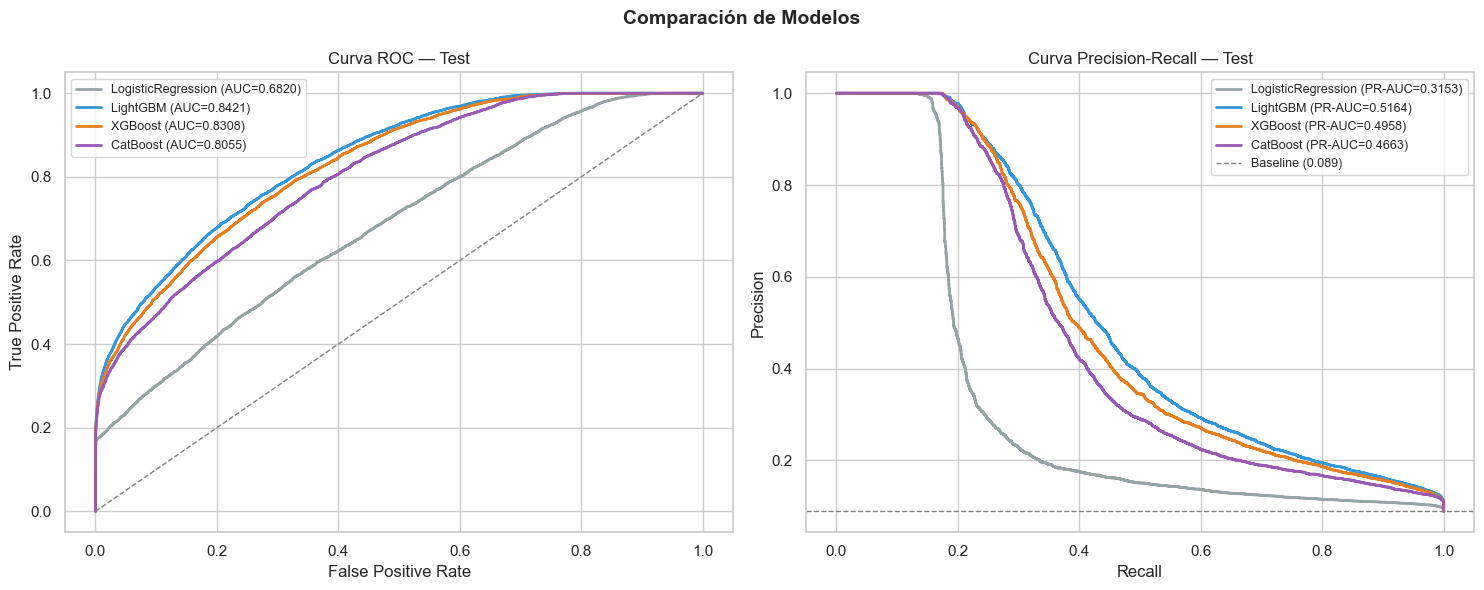

In [9]:
# Curvas ROC — todos los modelos sobre test
model_colors = {
    'LogisticRegression': '#95a5a6',
    'LightGBM'          : '#3498db',
    'XGBoost'           : '#e67e22',
    'CatBoost'          : '#9b59b6'
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ROC
for r in [r for r in results if r['split'] == 'test']:
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    axes[0].plot(fpr, tpr, label=f"{r['model']} (AUC={r['auc_roc']:.4f})",
                 color=model_colors[r['model']], linewidth=2)
axes[0].plot([0,1],[0,1],'--', color='gray', linewidth=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Curva ROC — Test')
axes[0].legend(fontsize=9)

# Precision-Recall
for r in [r for r in results if r['split'] == 'test']:
    prec, rec, _ = precision_recall_curve(y_test, r['y_prob'])
    axes[1].plot(rec, prec, label=f"{r['model']} (PR-AUC={r['pr_auc']:.4f})",
                 color=model_colors[r['model']], linewidth=2)
baseline = y_test.mean()
axes[1].axhline(baseline, linestyle='--', color='gray', linewidth=1, label=f'Baseline ({baseline:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall — Test')
axes[1].legend(fontsize=9)

plt.suptitle('Comparación de Modelos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}model_comparison_curves.png', dpi=150, bbox_inches='tight')
plt.show()

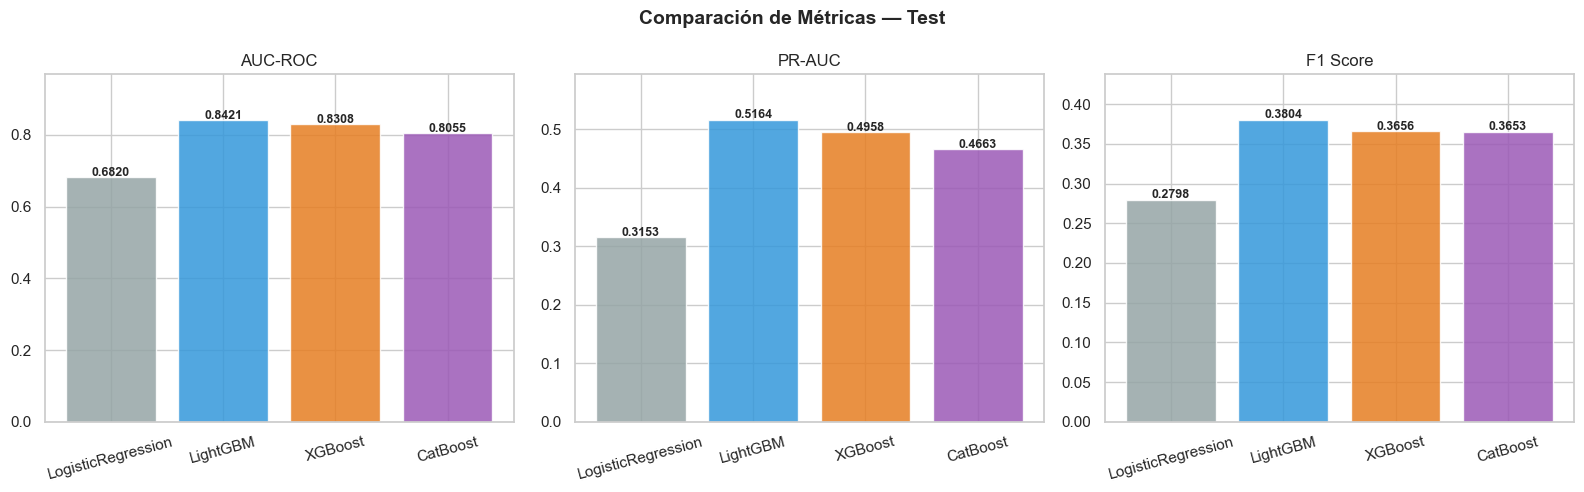

In [10]:
# Barplot comparativo de métricas
metrics = ['auc_roc', 'pr_auc', 'f1']
model_order = ['LogisticRegression', 'LightGBM', 'XGBoost', 'CatBoost']

test_pivot = results_df[results_df['split']=='test'].set_index('model')[metrics]
test_pivot = test_pivot.reindex(model_order)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metric_labels = {'auc_roc': 'AUC-ROC', 'pr_auc': 'PR-AUC', 'f1': 'F1 Score'}

for i, metric in enumerate(metrics):
    bars = axes[i].bar(model_order, test_pivot[metric],
                       color=[model_colors[m] for m in model_order],
                       alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, test_pivot[metric]):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.002,
                     f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
    axes[i].set_title(metric_labels[metric])
    axes[i].set_ylim(0, test_pivot[metric].max() * 1.15)
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Comparación de Métricas — Test', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}model_metrics_bar.png', dpi=150, bbox_inches='tight')
plt.show()

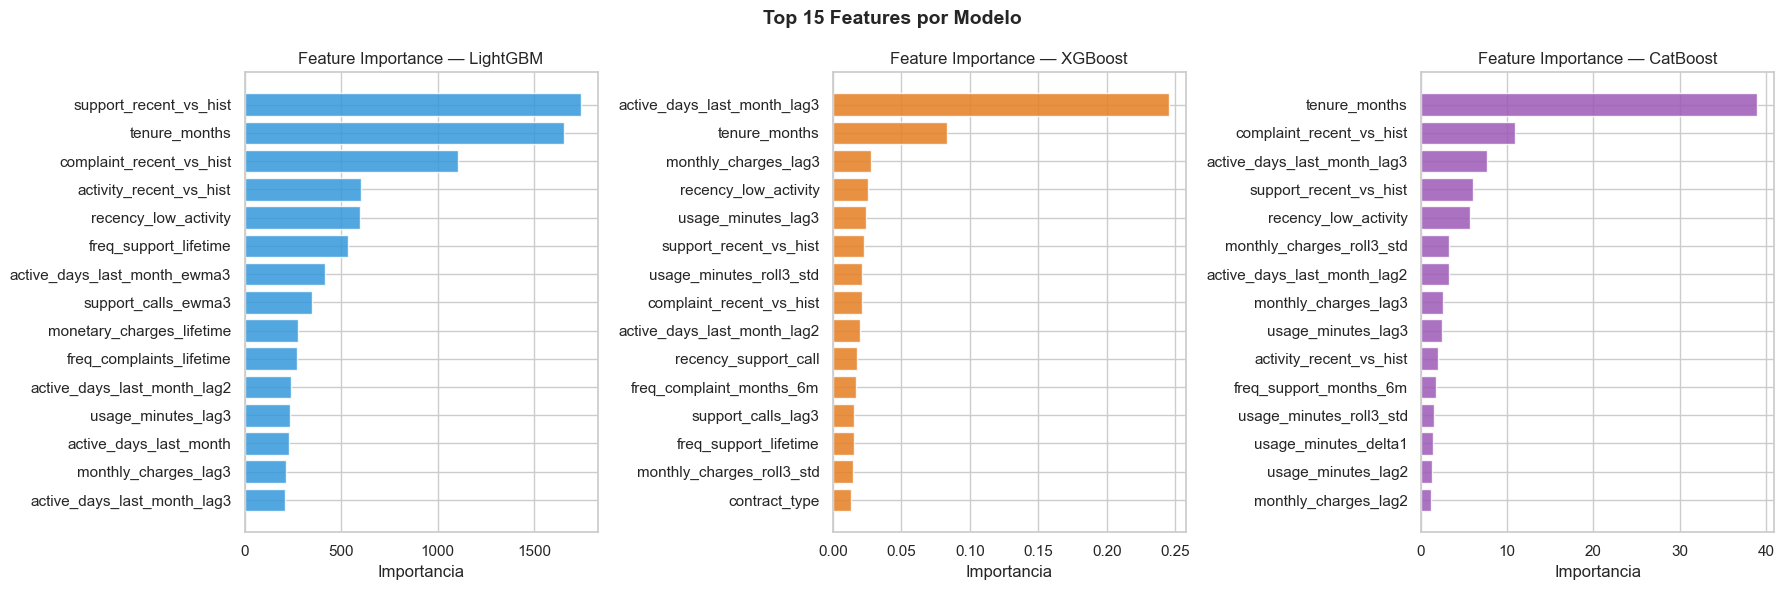

In [11]:
# Feature importance — modelos boosting
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
top_n = 15

boost_models = {
    'LightGBM' : (lgbm_model, lgbm_model.feature_importances_),
    'XGBoost'  : (xgb_model,  xgb_model.feature_importances_),
    'CatBoost' : (cat_model,  cat_model.get_feature_importance())
}

for i, (name, (_, importances)) in enumerate(boost_models.items()):
    fi = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(top_n)
    axes[i].barh(fi.index[::-1], fi.values[::-1],
                 color=model_colors[name], alpha=0.85, edgecolor='white')
    axes[i].set_title(f'Feature Importance — {name}')
    axes[i].set_xlabel('Importancia')

plt.suptitle(f'Top {top_n} Features por Modelo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Overfitting check: val vs test por modelo
print('=== Overfitting check (Val vs Test AUC-ROC) ===')
print(f'{"Modelo":<22} {"Val":>8} {"Test":>8} {"Δ (val-test)":>12}')
print('-' * 52)
for m in model_order:
    v = results_df[(results_df['model']==m) & (results_df['split']=='val')]['auc_roc'].values[0]
    t = results_df[(results_df['model']==m) & (results_df['split']=='test')]['auc_roc'].values[0]
    flag = ' ⚠' if abs(v - t) > 0.02 else ' ✓'
    print(f'{m:<22} {v:>8.4f} {t:>8.4f} {v-t:>+12.4f}{flag}')

=== Overfitting check (Val vs Test AUC-ROC) ===
Modelo                      Val     Test Δ (val-test)
----------------------------------------------------
LogisticRegression       0.6819   0.6820      -0.0001 ✓
LightGBM                 0.8584   0.8421      +0.0163 ✓
XGBoost                  0.8485   0.8308      +0.0177 ✓
CatBoost                 0.8245   0.8055      +0.0190 ✓


## 8. Hyperparameter Tuning — LightGBM con Optuna

Optimización bayesiana sobre el espacio de hiperparámetros de LightGBM.
- **Métrica objetivo**: Val AUC-ROC (el test nunca interviene en el tuning)
- **50 trials** con early stopping por trial (100 rounds sin mejora)
- Los mejores parámetros se usan para reentrenar el modelo final

In [13]:
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── LIGHTGBM OPTUNA (50 trials) ──────────────────────────────────
lgbm_callbacks = [lgb.early_stopping(stopping_rounds=50, verbose=False),
                  lgb.log_evaluation(period=-1)]

def lgbm_objective(trial):
    params = {
        'n_estimators'      : trial.suggest_int('n_estimators', 200, 1500),
        'max_depth'         : trial.suggest_int('max_depth', 3, 8),
        'num_leaves'        : trial.suggest_int('num_leaves', 20, 200),
        'learning_rate'     : trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'min_child_samples' : trial.suggest_int('min_child_samples', 10, 100),
        'subsample'         : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha'         : trial.suggest_float('reg_alpha', 1e-4, 5.0, log=True),
        'reg_lambda'        : trial.suggest_float('reg_lambda', 1e-4, 5.0, log=True),
        'random_state': RANDOM_STATE, 'n_jobs': -1, 'verbose': -1,
    }
    m = lgb.LGBMClassifier(**params)
    m.fit(X_train, y_train, eval_set=[(X_val, y_val)], callbacks=lgbm_callbacks)
    return roc_auc_score(y_val, m.predict_proba(X_val)[:, 1])

print('Optuna LightGBM — 50 trials...')
t0 = time.time()
study_lgbm = optuna.create_study(direction='maximize', sampler=TPESampler(seed=RANDOM_STATE))
study_lgbm.optimize(lgbm_objective, n_trials=50, show_progress_bar=False)
print(f'  → {time.time()-t0:.0f}s | Best Val AUC: {study_lgbm.best_value:.4f}  Gini: {2*study_lgbm.best_value-1:.4f}')

# ── CATBOOST OPTUNA (40 trials, iterations limitadas) ────────────
def cat_objective(trial):
    params = {
        'iterations'        : trial.suggest_int('iterations', 100, 500),
        'depth'             : trial.suggest_int('depth', 3, 8),
        'learning_rate'     : trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'l2_leaf_reg'       : trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        'subsample'         : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bylevel' : trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        'min_data_in_leaf'  : trial.suggest_int('min_data_in_leaf', 5, 50),
        'eval_metric': 'AUC', 'early_stopping_rounds': 50,
        'random_seed': RANDOM_STATE, 'thread_count': -1, 'verbose': False,
    }
    m = CatBoostClassifier(**params)
    m.fit(X_train, y_train, eval_set=(X_val, y_val), verbose=False)
    return roc_auc_score(y_val, m.predict_proba(X_val)[:, 1])

print('Optuna CatBoost  — 40 trials...')
t0 = time.time()
study_cat = optuna.create_study(direction='maximize', sampler=TPESampler(seed=RANDOM_STATE))
study_cat.optimize(cat_objective, n_trials=40, show_progress_bar=False)
print(f'  → {time.time()-t0:.0f}s | Best Val AUC: {study_cat.best_value:.4f}  Gini: {2*study_cat.best_value-1:.4f}')


Optuna LightGBM — 50 trials...


  → 761s | Best Val AUC: 0.8696  Gini: 0.7393
Optuna CatBoost  — 40 trials...


  → 257s | Best Val AUC: 0.8459  Gini: 0.6918


In [14]:
# ── LightGBM Tuned ────────────────────────────────────────────────
t0 = time.time()
lgbm_params = study_lgbm.best_params.copy()
lgbm_params.update({'random_state': RANDOM_STATE, 'n_jobs': -1, 'verbose': -1})
lgbm_tuned = lgb.LGBMClassifier(**lgbm_params)
lgbm_tuned.fit(X_train, y_train)
print(f'LightGBM Tuned entrenado en {time.time()-t0:.0f}s')

for split_name, Xs, ys in [('val', X_val, y_val), ('test', X_test, y_test), ('oot', X_oot, y_oot)]:
    r = evaluate_model(lgbm_tuned, Xs, ys, 'LightGBM_Tuned', split_name)
    results.append(r)

# ── CatBoost Tuned ────────────────────────────────────────────────
t0 = time.time()
cat_params = study_cat.best_params.copy()
cat_params.update({'random_seed': RANDOM_STATE, 'thread_count': -1, 'verbose': False})
cat_tuned = CatBoostClassifier(**cat_params)
cat_tuned.fit(X_train, y_train, verbose=False)
print(f'CatBoost  Tuned entrenado en {time.time()-t0:.0f}s')

for split_name, Xs, ys in [('val', X_val, y_val), ('test', X_test, y_test), ('oot', X_oot, y_oot)]:
    r = evaluate_model(cat_tuned, Xs, ys, 'CatBoost_Tuned', split_name)
    results.append(r)

# ── Comparación ──────────────────────────────────────────────────
print('\n=== BASELINE vs TUNED (Val) ===')
for mname in ['LightGBM', 'LightGBM_Tuned', 'CatBoost', 'CatBoost_Tuned']:
    r = next((x for x in results if x['model']==mname and x['split']=='val'), None)
    if r:
        print(f'  {mname:<20}: AUC={r["auc_roc"]:.4f} Gini={2*r["auc_roc"]-1:.4f}')

res_tuned_val  = next(x for x in results if x['model']=='LightGBM_Tuned' and x['split']=='val')
res_tuned_test = next(x for x in results if x['model']=='LightGBM_Tuned' and x['split']=='test')
res_tuned_oot  = next(x for x in results if x['model']=='LightGBM_Tuned' and x['split']=='oot')


LightGBM Tuned entrenado en 28s


CatBoost  Tuned entrenado en 10s

=== BASELINE vs TUNED (Val) ===
  LightGBM            : AUC=0.8584 Gini=0.7168
  LightGBM_Tuned      : AUC=0.8695 Gini=0.7390
  CatBoost            : AUC=0.8245 Gini=0.6490
  CatBoost_Tuned      : AUC=0.8445 Gini=0.6890


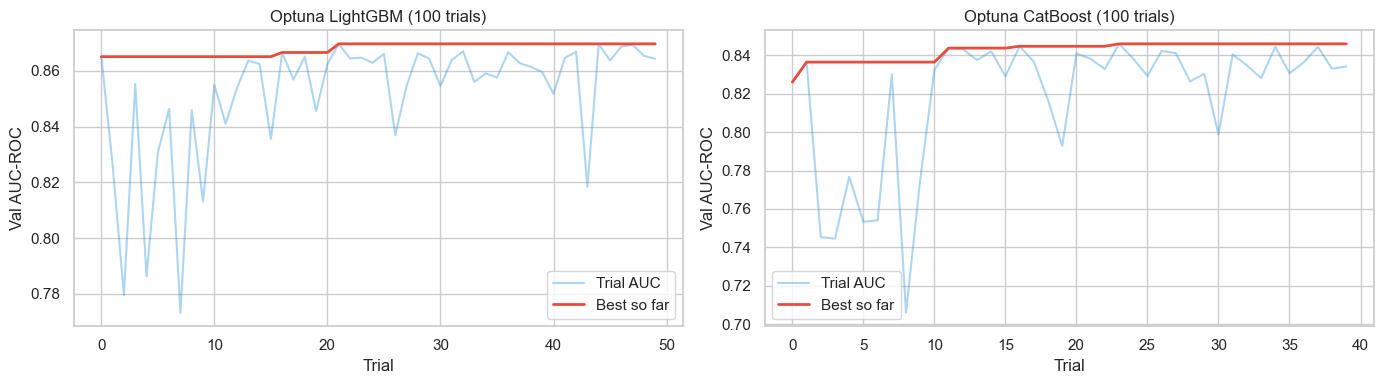

Pesos del ensemble:
  LightGBM_Tuned      : 0.3425
  CatBoost_Tuned      : 0.3327
  CatBoost            : 0.3248



=== ENSEMBLE vs BEST SINGLE ===
  CatBoost_Tuned       val  : AUC=0.8445 Gini=0.6890
  CatBoost_Tuned       test : AUC=0.8279 Gini=0.6558
  CatBoost_Tuned       oot  : AUC=0.7458 Gini=0.4916

  LightGBM_Tuned       val  : AUC=0.8695 Gini=0.7390
  LightGBM_Tuned       test : AUC=0.8610 Gini=0.7220
  LightGBM_Tuned       oot  : AUC=0.7622 Gini=0.5244

  Ensemble_Top3        val  : AUC=0.8665 Gini=0.7330
  Ensemble_Top3        test : AUC=0.8522 Gini=0.7044
  Ensemble_Top3        oot  : AUC=0.7584 Gini=0.5168



In [15]:
# ── Curva de optimización Optuna ─────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, study, title in [(axes[0], study_lgbm, 'LightGBM'), (axes[1], study_cat, 'CatBoost')]:
    trials_auc = [t.value for t in study.trials if t.value is not None]
    best_so_far = [max(trials_auc[:i+1]) for i in range(len(trials_auc))]
    ax.plot(trials_auc, alpha=0.4, color='#3498db', label='Trial AUC')
    ax.plot(best_so_far, color='#e74c3c', linewidth=2, label='Best so far')
    ax.set_title(f'Optuna {title} (100 trials)')
    ax.set_xlabel('Trial')
    ax.set_ylabel('Val AUC-ROC')
    ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}optuna_convergence_v2.png', dpi=150, bbox_inches='tight')
plt.show()

# ── ENSEMBLE: promedio ponderado top 3 ───────────────────────────
# Pesos proporcionales al Val AUC de cada modelo
ensemble_candidates = ['LightGBM_Tuned', 'CatBoost_Tuned', 'CatBoost']
ensemble_models = {'LightGBM_Tuned': lgbm_tuned, 'CatBoost_Tuned': cat_tuned, 'CatBoost': cat_model}

val_aucs = {}
for name in ensemble_candidates:
    r = next(x for x in results if x['model']==name and x['split']=='val')
    val_aucs[name] = r['auc_roc']
total_auc = sum(val_aucs.values())
weights   = {k: v/total_auc for k, v in val_aucs.items()}
print('Pesos del ensemble:')
for k, w in weights.items():
    print(f'  {k:<20}: {w:.4f}')

def ensemble_predict(X):
    probs = [ensemble_models[name].predict_proba(X)[:, 1] * weights[name]
             for name in ensemble_candidates]
    return sum(probs)

for split_name, Xs, ys in [('val', X_val, y_val), ('test', X_test, y_test), ('oot', X_oot, y_oot)]:
    y_prob_ens = ensemble_predict(Xs)
    auc  = roc_auc_score(ys, y_prob_ens)
    prauc = average_precision_score(ys, y_prob_ens)
    results.append({'model': 'Ensemble_Top3', 'split': split_name,
                    'auc_roc': round(auc, 4), 'pr_auc': round(prauc, 4),
                    'f1': 0.0, 'y_prob': y_prob_ens})

print('\n=== ENSEMBLE vs BEST SINGLE ===')
for mname in ['CatBoost_Tuned', 'LightGBM_Tuned', 'Ensemble_Top3']:
    for s in ['val', 'test', 'oot']:
        r = next((x for x in results if x['model']==mname and x['split']==s), None)
        if r:
            print(f'  {mname:<20} {s:5}: AUC={r["auc_roc"]:.4f} Gini={2*r["auc_roc"]-1:.4f}')
    print()


## 9. Selección y guardado del mejor modelo

In [16]:
results_df = pd.DataFrame(results)

models = {
    'LogisticRegression' : lr,
    'LightGBM'           : lgbm_model,
    'XGBoost'            : xgb_model,
    'CatBoost'           : cat_model,
    'LightGBM_Tuned'     : lgbm_tuned,
    'CatBoost_Tuned'     : cat_tuned,
}

# Selección por Val AUC (excluyendo Ensemble ya que requiere tratamiento especial)
val_df = results_df[results_df['split']=='val'].copy()
best_row   = val_df.sort_values('auc_roc', ascending=False).iloc[0]
best_name  = best_row['model']

if best_name == 'Ensemble_Top3':
    best_model = None  # ensemble no se puede serializar directamente
    print('Mejor modelo: Ensemble_Top3 (no serializable, se guardan los componentes)')
else:
    best_model = models[best_name]

best_test = results_df[(results_df['model']==best_name) & (results_df['split']=='test')].iloc[0]
best_oot  = results_df[(results_df['model']==best_name) & (results_df['split']=='oot')].iloc[0]

print(f'Mejor modelo : {best_name}')
print(f'  Val  AUC : {best_row["auc_roc"]:.4f}  Gini : {2*best_row["auc_roc"]-1:.4f}')
print(f'  Test AUC : {best_test["auc_roc"]:.4f}  Gini : {2*best_test["auc_roc"]-1:.4f}')
print(f'  OOT  AUC : {best_oot["auc_roc"]:.4f}  Gini : {2*best_oot["auc_roc"]-1:.4f}')
print()

# Tabla completa
summary = results_df[results_df['split'].isin(['val','test','oot'])].copy()
summary['gini'] = (2 * summary['auc_roc'] - 1).round(4)
pivot = summary.pivot_table(index='model', columns='split', values='gini')
print('=== GINI POR MODELO Y SPLIT ===')
print(pivot[['val','test','oot']].sort_values('val', ascending=False).to_string(float_format='{:.4f}'.format))


Mejor modelo : LightGBM_Tuned
  Val  AUC : 0.8695  Gini : 0.7390
  Test AUC : 0.8610  Gini : 0.7220
  OOT  AUC : 0.7622  Gini : 0.5244

=== GINI POR MODELO Y SPLIT ===
split                 val   test    oot
model                                  
LightGBM_Tuned     0.7390 0.7220 0.5244
Ensemble_Top3      0.7330 0.7044 0.5168
LightGBM           0.7168 0.6842 0.5004
XGBoost            0.6970 0.6616 0.4714
CatBoost_Tuned     0.6890 0.6558 0.4916
CatBoost           0.6490 0.6110 0.4438
LogisticRegression 0.3638 0.3640 0.2368


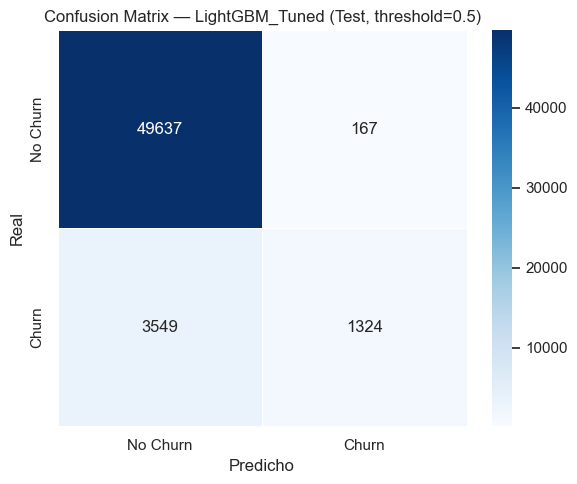

              precision    recall  f1-score   support

    No Churn       0.93      1.00      0.96     49804
       Churn       0.89      0.27      0.42      4873

    accuracy                           0.93     54677
   macro avg       0.91      0.63      0.69     54677
weighted avg       0.93      0.93      0.92     54677



In [17]:
# Confusion matrix del mejor modelo en test
y_prob_best = best_model.predict_proba(X_test)[:, 1]
y_pred_best = (y_prob_best >= 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'],
            linewidths=0.5)
ax.set_xlabel('Predicho')
ax.set_ylabel('Real')
ax.set_title(f'Confusion Matrix — {best_name} (Test, threshold=0.5)')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}confusion_matrix_best.png', dpi=150, bbox_inches='tight')
plt.show()

print(classification_report(y_test, y_pred_best, target_names=['No Churn', 'Churn']))

In [18]:
version    = 'v2.0'
timestamp  = datetime.now().strftime('%Y%m%d_%H%M')

# Guardar el mejor modelo single (no ensemble)
best_single_row  = results_df[(results_df['split']=='val') & (results_df['model']!='Ensemble_Top3')].sort_values('auc_roc', ascending=False).iloc[0]
best_single_name = best_single_row['model']
best_single      = models[best_single_name]

# Guardar componentes del ensemble
model_name = f'{best_single_name.lower()}_{version}_{timestamp}'
joblib.dump(best_single, f'{TRAINED_PATH}{model_name}.pkl')
joblib.dump(lgbm_tuned, f'{TRAINED_PATH}lgbm_tuned_{version}_{timestamp}.pkl')
joblib.dump(cat_tuned,  f'{TRAINED_PATH}cat_tuned_{version}_{timestamp}.pkl')

metrics_output = results_df.drop(columns=['y_prob']).to_dict(orient='records')

best_s_test = results_df[(results_df['model']==best_single_name) & (results_df['split']=='test')].iloc[0]
best_s_oot  = results_df[(results_df['model']==best_single_name) & (results_df['split']=='oot')].iloc[0]

model_metadata = {
    'version'                : version,
    'timestamp'              : timestamp,
    'best_model'             : best_single_name,
    'model_file'             : f'{model_name}.pkl',
    'lgbm_tuned_file'        : f'lgbm_tuned_{version}_{timestamp}.pkl',
    'cat_tuned_file'         : f'cat_tuned_{version}_{timestamp}.pkl',
    'preprocessor_file'      : 'preprocessor_v1.pkl',
    'target'                 : 'churn_next_month',
    'split_strategy'         : 'temporal',
    'features'               : feature_names,
    'n_features'             : len(feature_names),
    'balancing'              : 'none',
    'val_auc_roc'            : float(best_single_row['auc_roc']),
    'val_pr_auc'             : float(best_single_row['pr_auc']),
    'test_auc_roc'           : float(best_s_test['auc_roc']),
    'test_pr_auc'            : float(best_s_test['pr_auc']),
    'oot_auc_roc'            : float(best_s_oot['auc_roc']),
    'oot_pr_auc'             : float(best_s_oot['pr_auc']),
    'all_models_results'     : metrics_output
}

with open(f'{REGISTRY_PATH}model_metadata_{version}.json', 'w') as f:
    json.dump(model_metadata, f, indent=2)

with open(f'{METRICS_PATH}all_models_metrics.json', 'w') as f:
    json.dump(metrics_output, f, indent=2)

print(f'Modelo guardado      : {TRAINED_PATH}{model_name}.pkl')
print(f'Metadata             : {REGISTRY_PATH}model_metadata_{version}.json')
print()
print('✓ Listo para notebook 04_evaluation.ipynb')


Modelo guardado      : ../models/trained/lightgbm_tuned_v2.0_20260412_0239.pkl
Metadata             : ../models/registry/model_metadata_v2.0.json

✓ Listo para notebook 04_evaluation.ipynb
